In [ ]:
from rbfPUCurlNoise.triang_mesh          import TriMesh, refine_mesh_1to4
from rbfPUCurlNoise.patches       import PatchCoverage
from rbfPUCurlNoise.rbf           import RBF
from rbfPUCurlNoise.interpolator  import PUMInterpolator
from rbfPUCurlNoise.potential import NoisePotential2D
from rbfPUCurlNoise.utils import plot_noise_mesh, plot_mesh, plot_layers_mesh, refine_around_brder
from rbfPUCurlNoise.visualization import plot_patches, plot_patches_v2, plot_combined_field
from perlin_noise import PerlinNoise
import triangle
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
noise_seed = 7
freq = 1

noise = PerlinNoise(octaves=3, seed=noise_seed)

-375.08 359.5
-1.0 1.0
-1.0 1.0


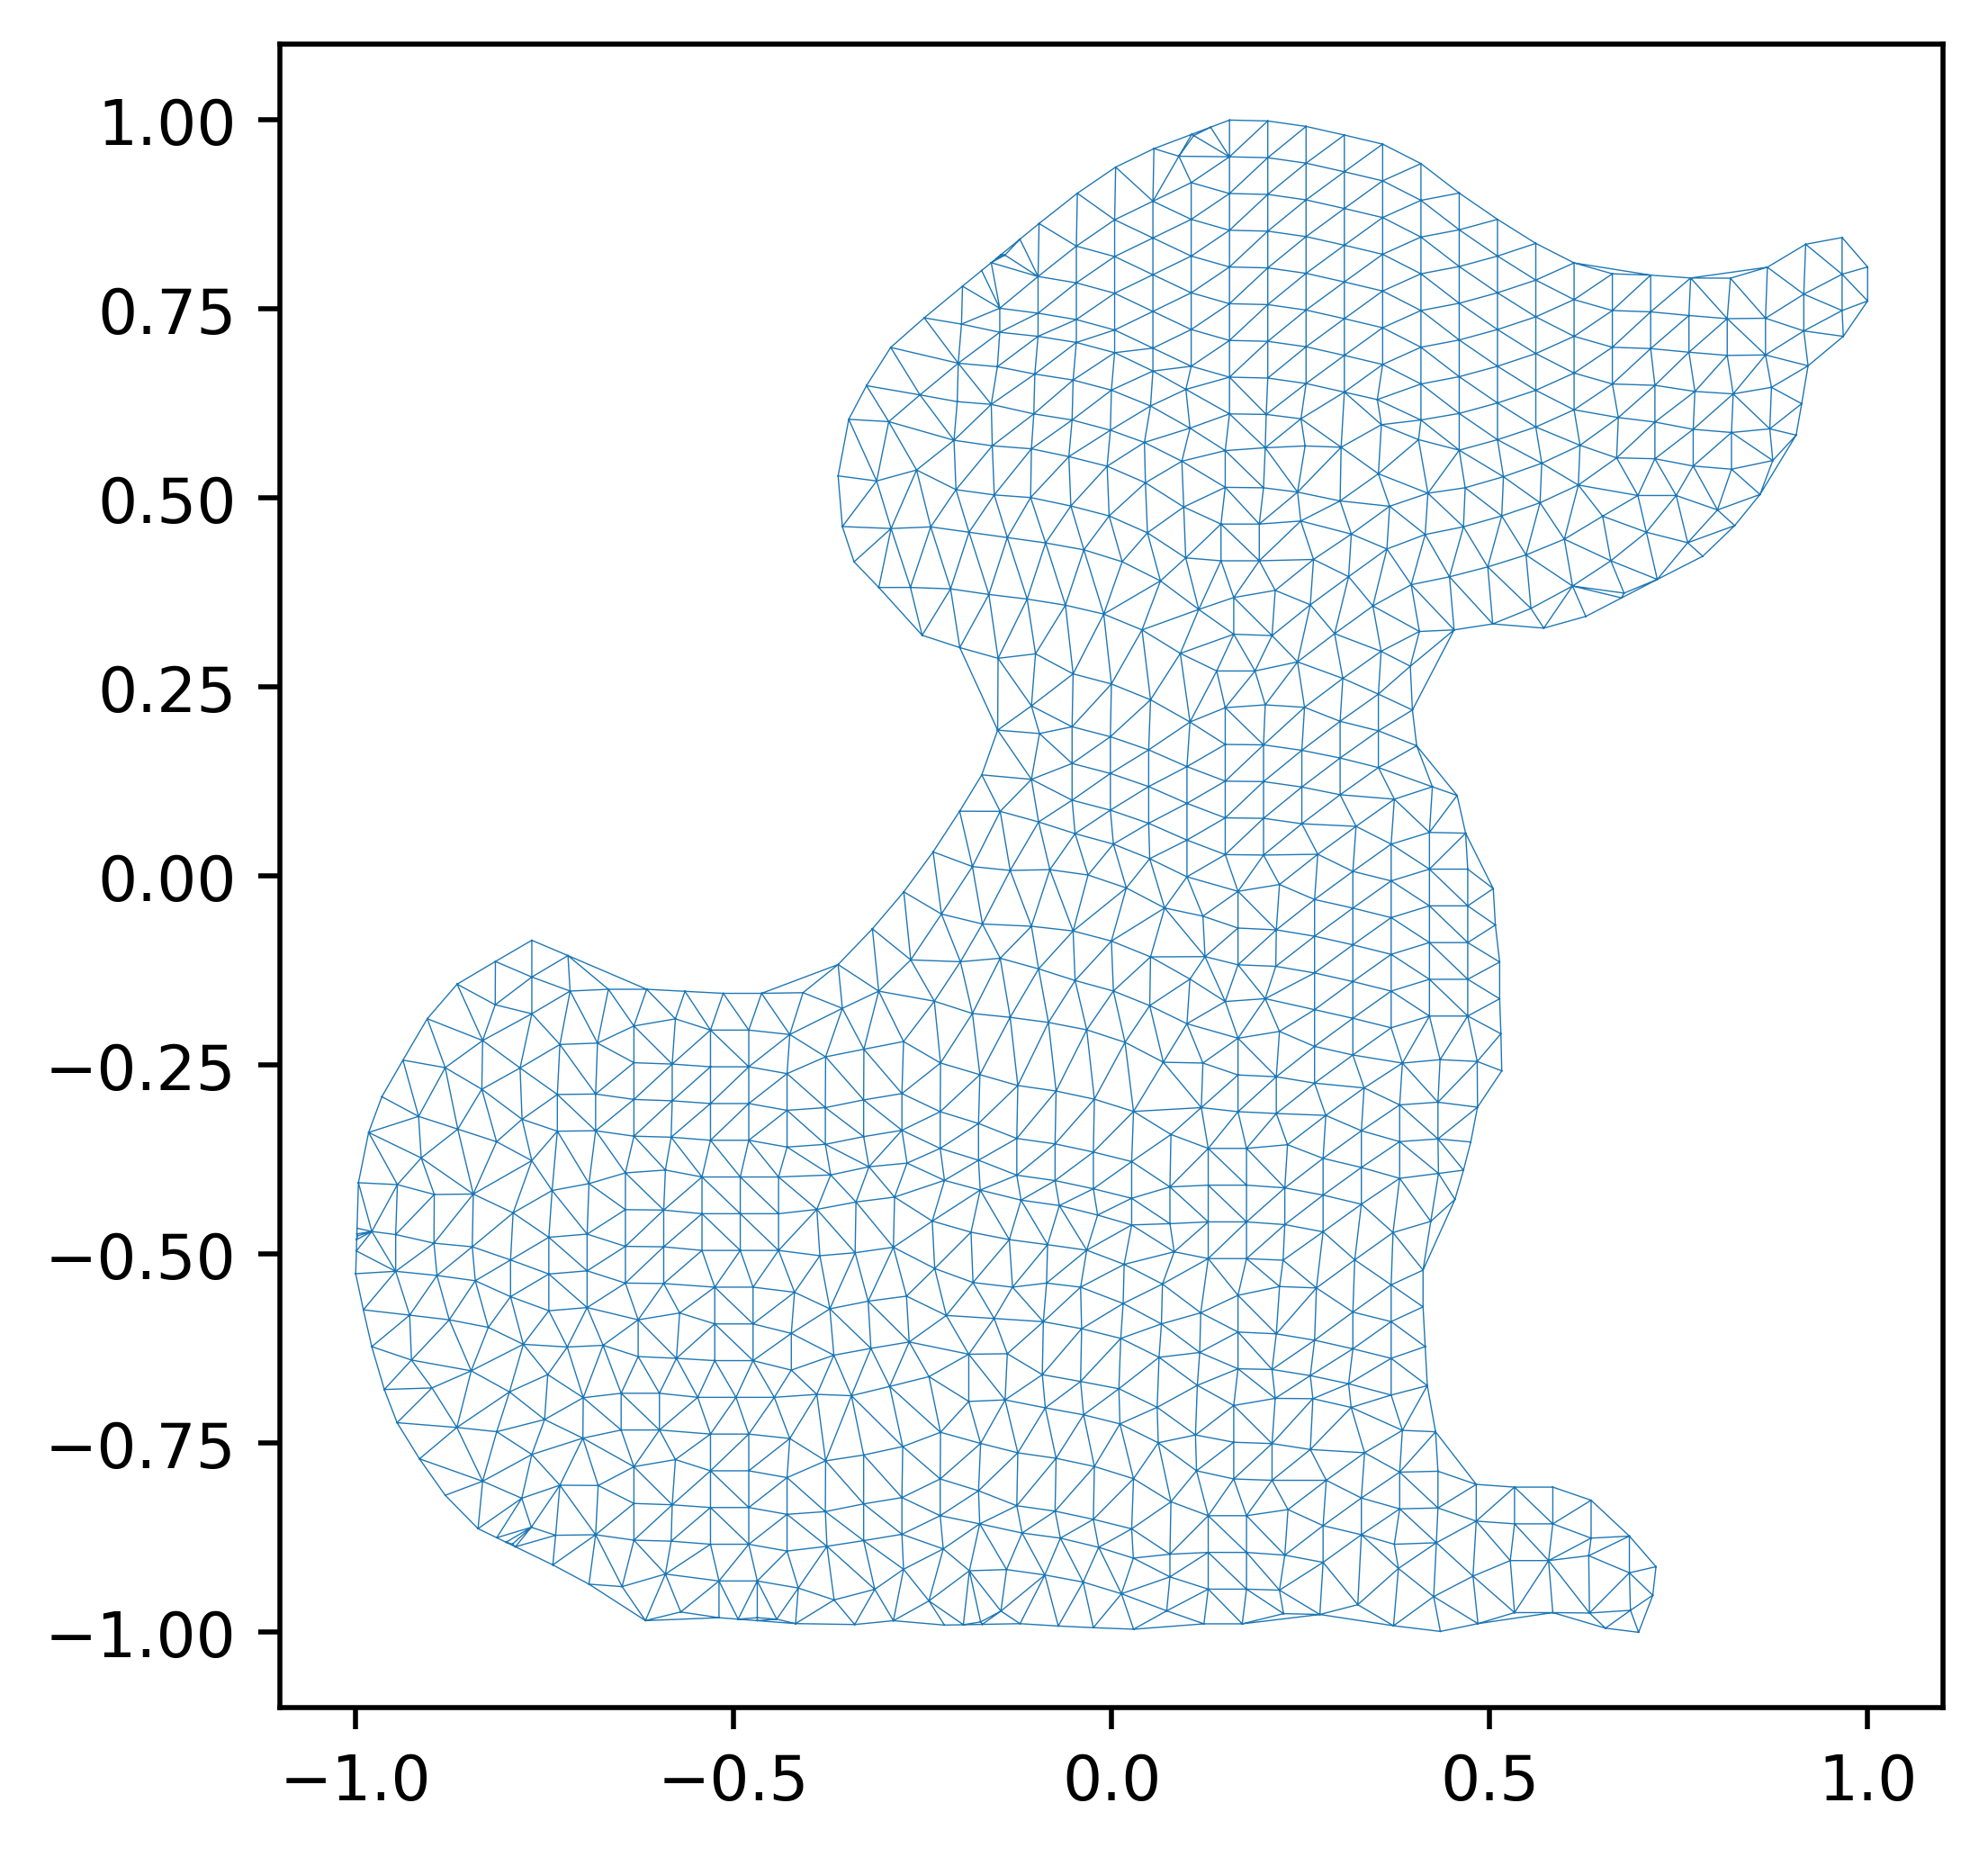

In [ ]:
dog = triangle.load("..\\meshes\\triangle_files", "dog")
dog_mesh = triangle.triangulate(dog, "pq5a150")

print(dog_mesh["vertices"].min(), dog_mesh["vertices"].max())
mins = dog_mesh["vertices"].min(axis=0)
maxs = dog_mesh["vertices"].max(axis=0)

# Normalizing mesh vertices range
dog_mesh["vertices"] = 2 * (dog_mesh["vertices"] - mins) / (maxs - mins) - 1
print(dog_mesh["vertices"].min(), dog_mesh["vertices"].max())
print(dog_mesh["vertices"].min(), dog_mesh["vertices"].max())

dog_mesh_obj = TriMesh(dog_mesh)
plot_mesh(dog_mesh)

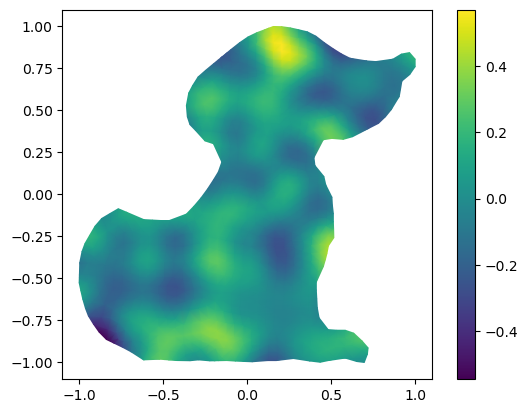

In [ ]:
mesh_noise = dog_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)
plot_noise_mesh(dog_mesh, mesh_noise)

(889,)
144
187
158
122
168
182
35
102
181
73
183
109

Resumo da cobertura:
  n_patches           : 11
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 73
  max_nodes           : 223
  mean_nodes          : 159.8181818181818
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 1.9775028121484814
  full_coverage       : True
[0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285]
(889,)


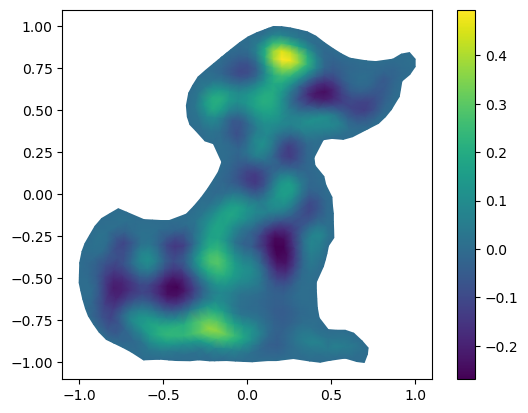

<Axes: title={'center': 'Coverage: 11 patches)'}>

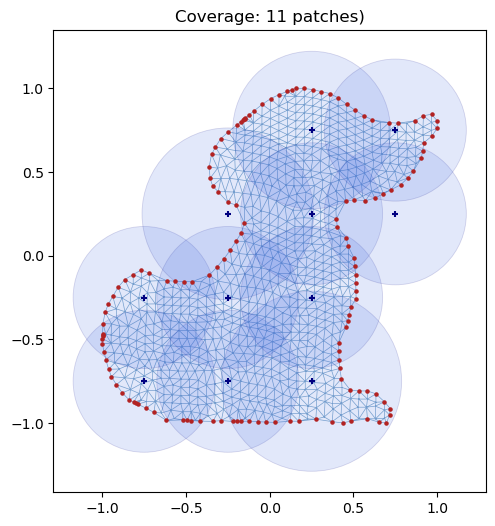

In [ ]:
dog_mesh_obj.sdf_distance_to_segments_min()
sdf = dog_mesh_obj.get_sdf_field()

coverage = PatchCoverage(dog_mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

print(coverage.radius_list)
epsilon = np.mean(coverage.radius_list)

potential_sdf = NoisePotential2D(dog_mesh_obj, coverage, RBF(epsilon=epsilon))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.2)
plot_noise_mesh(dog_mesh, psi)

plot_patches(dog_mesh_obj, coverage, ax=None, title=f"Coverage: {len(coverage)} patches)")

In [ ]:
# Without boundary treatment
potential_sdf.fit(mesh_noise)

grad_x, grad_y = potential_sdf.gradient(dog_mesh["vertices"])

print(grad_x.shape)
print(grad_y.shape)

curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))

print(curl.shape)

dog_mesh_obj.save_mesh_paraview(dog_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="dog_lic_noise.vtu", save_norm=True)

(889,)
(889,)
(889, 2)
Normalization factor: 0.5693242517649323
Original normalized range:
-0.9566654630554119 1.0
Masked normalized range:
-0.47262836526813223 0.868199252822307


In [ ]:
# With boundary treatment
potential_sdf.fit(psi)

grad_x, grad_y = potential_sdf.gradient(dog_mesh["vertices"])

print(grad_x.shape)
print(grad_y.shape)

curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))

print(curl.shape)

dog_mesh_obj.save_mesh_paraview(dog_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="dog_lic_psi.vtu", save_norm=True)

(889,)
(889,)
(889, 2)
Normalization factor: 0.5693242517649323
Original normalized range:
-0.9566654630554119 1.0
Masked normalized range:
-0.47262836526813223 0.868199252822307


-1001.81 828.5
-1.0 1.0


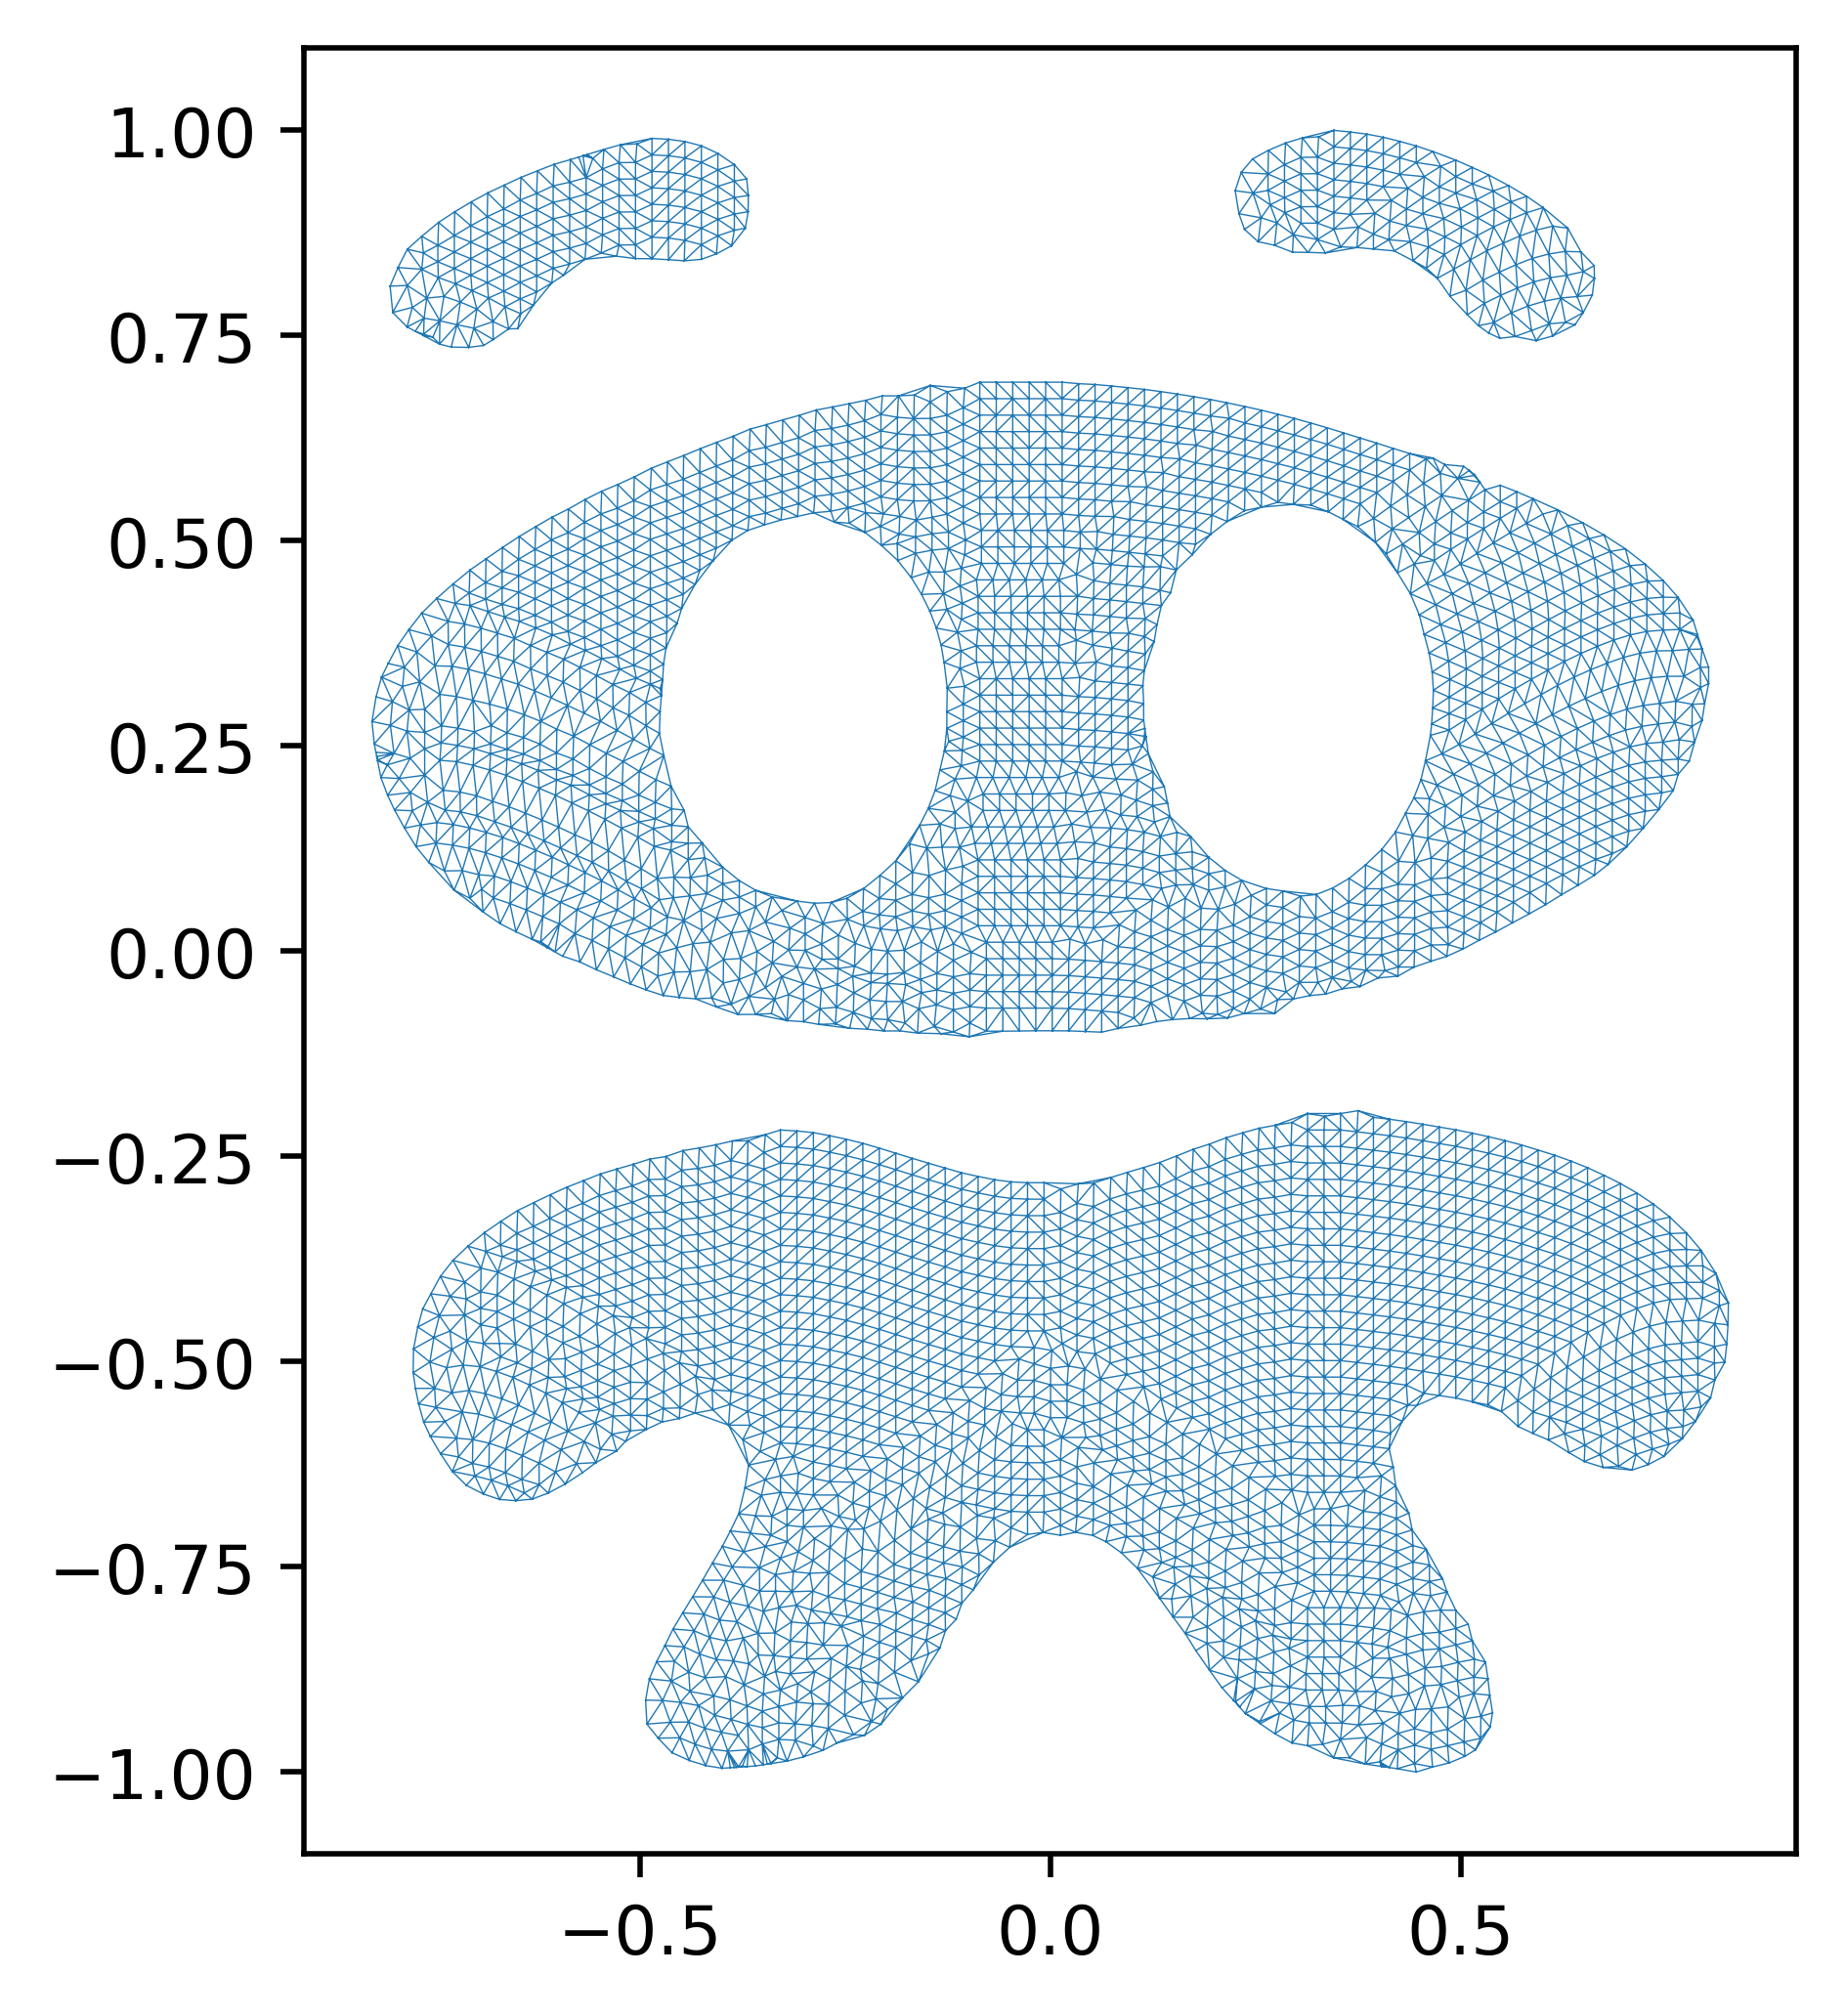

In [ ]:
alienbs = triangle.load("..\\meshes\\triangle_files", "alienbs")
alienbs_mesh = triangle.triangulate(alienbs, "pq5a150")

print(alienbs_mesh["vertices"].min(), alienbs_mesh["vertices"].max())
mins = alienbs_mesh["vertices"].min(axis=0)
maxs = alienbs_mesh["vertices"].max(axis=0)
# Center of the bounding box
center = 0.5 * (mins + maxs)

# Largest dimension of the bounding box
max_extent = np.max(maxs - mins)

# Normalizing mesh vertices range
alienbs_mesh["vertices"] = 2.0 * (alienbs_mesh["vertices"] - center) / max_extent
print(alienbs_mesh["vertices"].min(), alienbs_mesh["vertices"].max())

alienbs_mesh_obj = TriMesh(alienbs_mesh)
plot_mesh(alienbs_mesh)

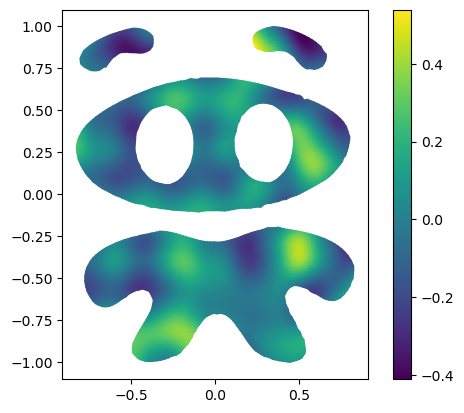

In [ ]:
mesh_noise = alienbs_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)
plot_noise_mesh(alienbs_mesh, mesh_noise)

(4159,)
565
874
730
666
1057
879
521
843
732
423
506
442

Resumo da cobertura:
  n_patches           : 12
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 423
  max_nodes           : 1058
  mean_nodes          : 712.0
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 2.054339985573455
  full_coverage       : True
[0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285]
(4159,)


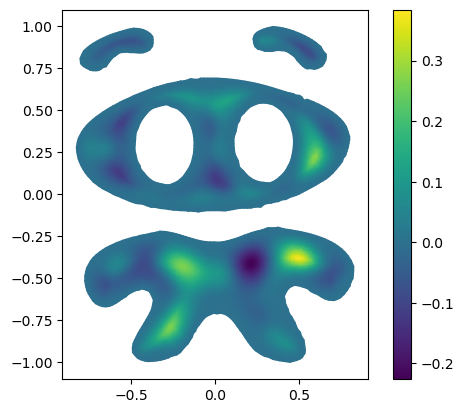

<Axes: title={'center': 'Coverage: 12 patches)'}>

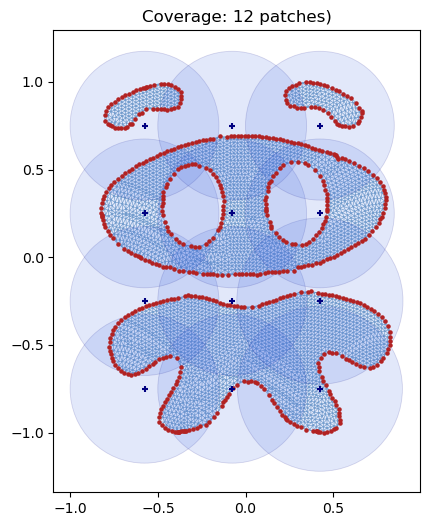

In [ ]:
alienbs_mesh_obj.sdf_distance_to_segments_min()
sdf = alienbs_mesh_obj.get_sdf_field()

coverage = PatchCoverage(alienbs_mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

print(coverage.radius_list)
epsilon = np.mean(coverage.radius_list)

potential_sdf = NoisePotential2D(alienbs_mesh_obj, coverage, RBF(epsilon=epsilon))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.2)
plot_noise_mesh(alienbs_mesh, psi)

plot_patches(alienbs_mesh_obj, coverage, ax=None, title=f"Coverage: {len(coverage)} patches)")

In [ ]:
# Without boundary treatment
potential_sdf.fit(mesh_noise)

grad_x, grad_y = potential_sdf.gradient(alienbs_mesh["vertices"])
curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))


alienbs_mesh_obj.save_mesh_paraview(alienbs_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="alienbs_lic_noise.vtu", save_norm=True)

Normalization factor: 0.539289539512672
Original normalized range:
-0.7629377844876416 1.0
Masked normalized range:
-0.4193000363226284 0.7122284478321232


In [ ]:
# With boundary treatment
potential_sdf.fit(psi)

grad_x, grad_y = potential_sdf.gradient(alienbs_mesh["vertices"])
curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))


alienbs_mesh_obj.save_mesh_paraview(alienbs_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="alienbs_lic_psi.vtu", save_norm=True)

Normalization factor: 0.539289539512672
Original normalized range:
-0.7629377844876416 1.0
Masked normalized range:
-0.4193000363226284 0.7122284478321232


-93.25 147.17
-0.9999999999999998 1.0


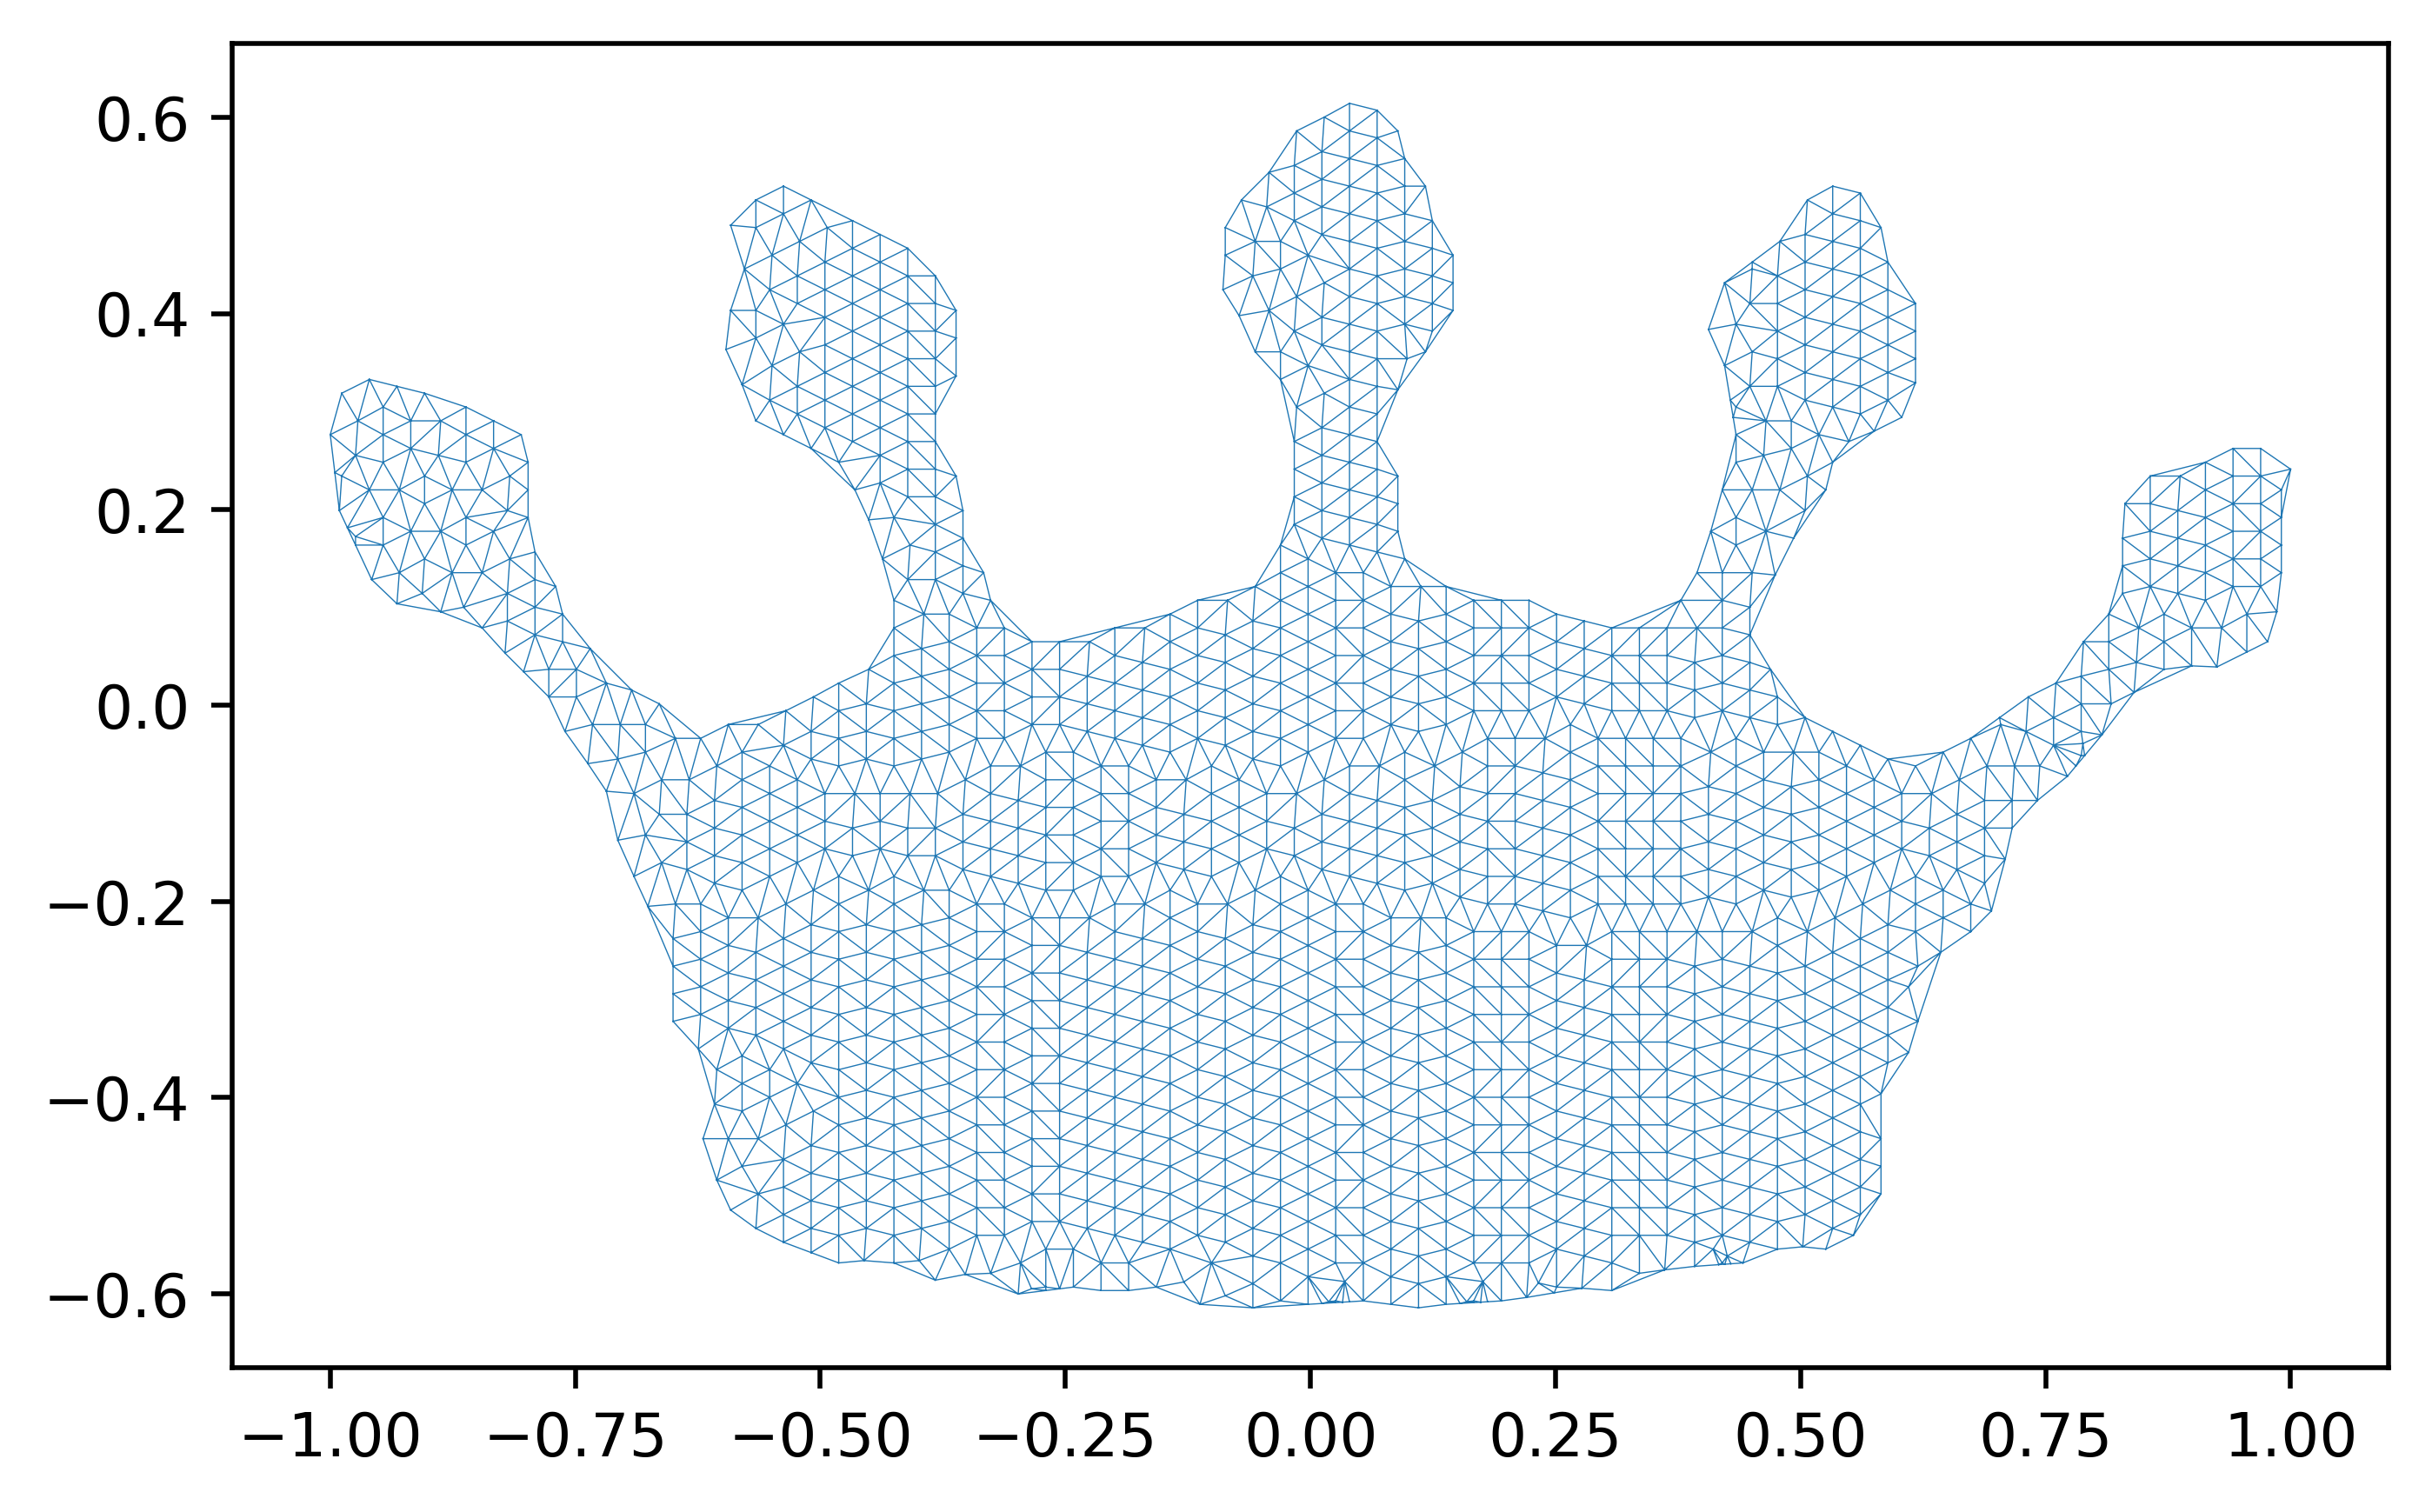

In [ ]:
crowndp = triangle.load("..\\meshes\\triangle_files", "crowndp")
crowndp_mesh = triangle.triangulate(crowndp, "pq10a150")

print(crowndp_mesh["vertices"].min(), crowndp_mesh["vertices"].max())
mins = crowndp_mesh["vertices"].min(axis=0)
maxs = crowndp_mesh["vertices"].max(axis=0)

# Center of the bounding box
center = 0.5 * (mins + maxs)

# Largest dimension of the bounding box
max_extent = np.max(maxs - mins)

# Normalizing mesh vertices range
crowndp_mesh["vertices"] = 2.0 * (crowndp_mesh["vertices"] - center) / max_extent
print(crowndp_mesh["vertices"].min(), crowndp_mesh["vertices"].max())

crowndp_mesh_obj = TriMesh(crowndp_mesh)
plot_mesh(crowndp_mesh)

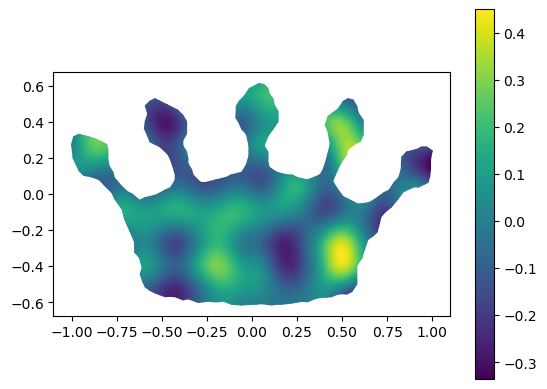

In [ ]:
mesh_noise = crowndp_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)
plot_noise_mesh(crowndp_mesh, mesh_noise)

(1530,)
574
584
247
430
441
249

Resumo da cobertura:
  n_patches           : 6
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 249
  max_nodes           : 689
  mean_nodes          : 509.6666666666667
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 1.9986928104575163
  full_coverage       : True
[0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285]
(1530,)


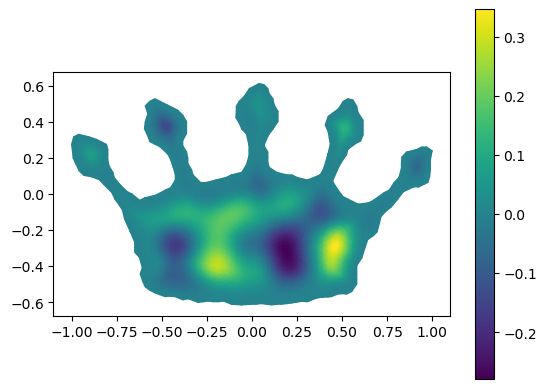

<Axes: title={'center': 'Coverage: 6 patches)'}>

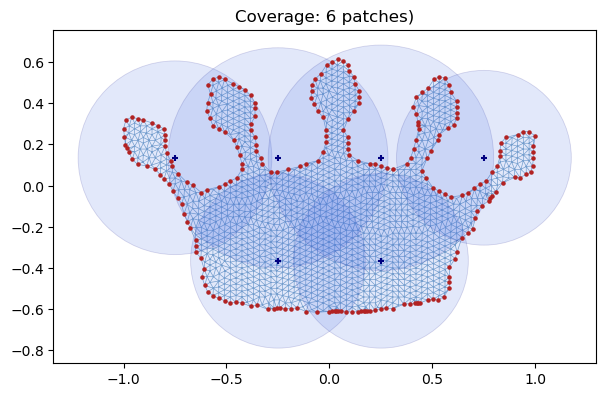

In [ ]:
crowndp_mesh_obj.sdf_distance_to_segments_min()
sdf = crowndp_mesh_obj.get_sdf_field()

coverage = PatchCoverage(crowndp_mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura
print(coverage.radius_list)

epsilon = np.mean(coverage.radius_list)

potential_sdf = NoisePotential2D(crowndp_mesh_obj, coverage, RBF(epsilon=epsilon))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.2)
plot_noise_mesh(crowndp_mesh, psi)

plot_patches(crowndp_mesh_obj, coverage, ax=None, title=f"Coverage: {len(coverage)} patches)")

In [ ]:
# Without boundary treatment
potential_sdf.fit(mesh_noise)

grad_x, grad_y = potential_sdf.gradient(crowndp_mesh["vertices"])
curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))


crowndp_mesh_obj.save_mesh_paraview(crowndp_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="crowndp_lic_noise.vtu", save_norm=True)

Normalization factor: 0.44914588308154313
Original normalized range:
-0.7459102472257317 1.0
Masked normalized range:
-0.6206249477935272 0.7714321653273403


In [ ]:
# With boundary treatment
potential_sdf.fit(psi)

grad_x, grad_y = potential_sdf.gradient(crowndp_mesh["vertices"])
curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))


crowndp_mesh_obj.save_mesh_paraview(crowndp_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="crowndp_lic_psi.vtu", save_norm=True)

Normalization factor: 0.44914588308154313
Original normalized range:
-0.7459102472257317 1.0
Masked normalized range:
-0.6206249477935272 0.7714321653273403


-83.5 111.0
-1.0 1.0


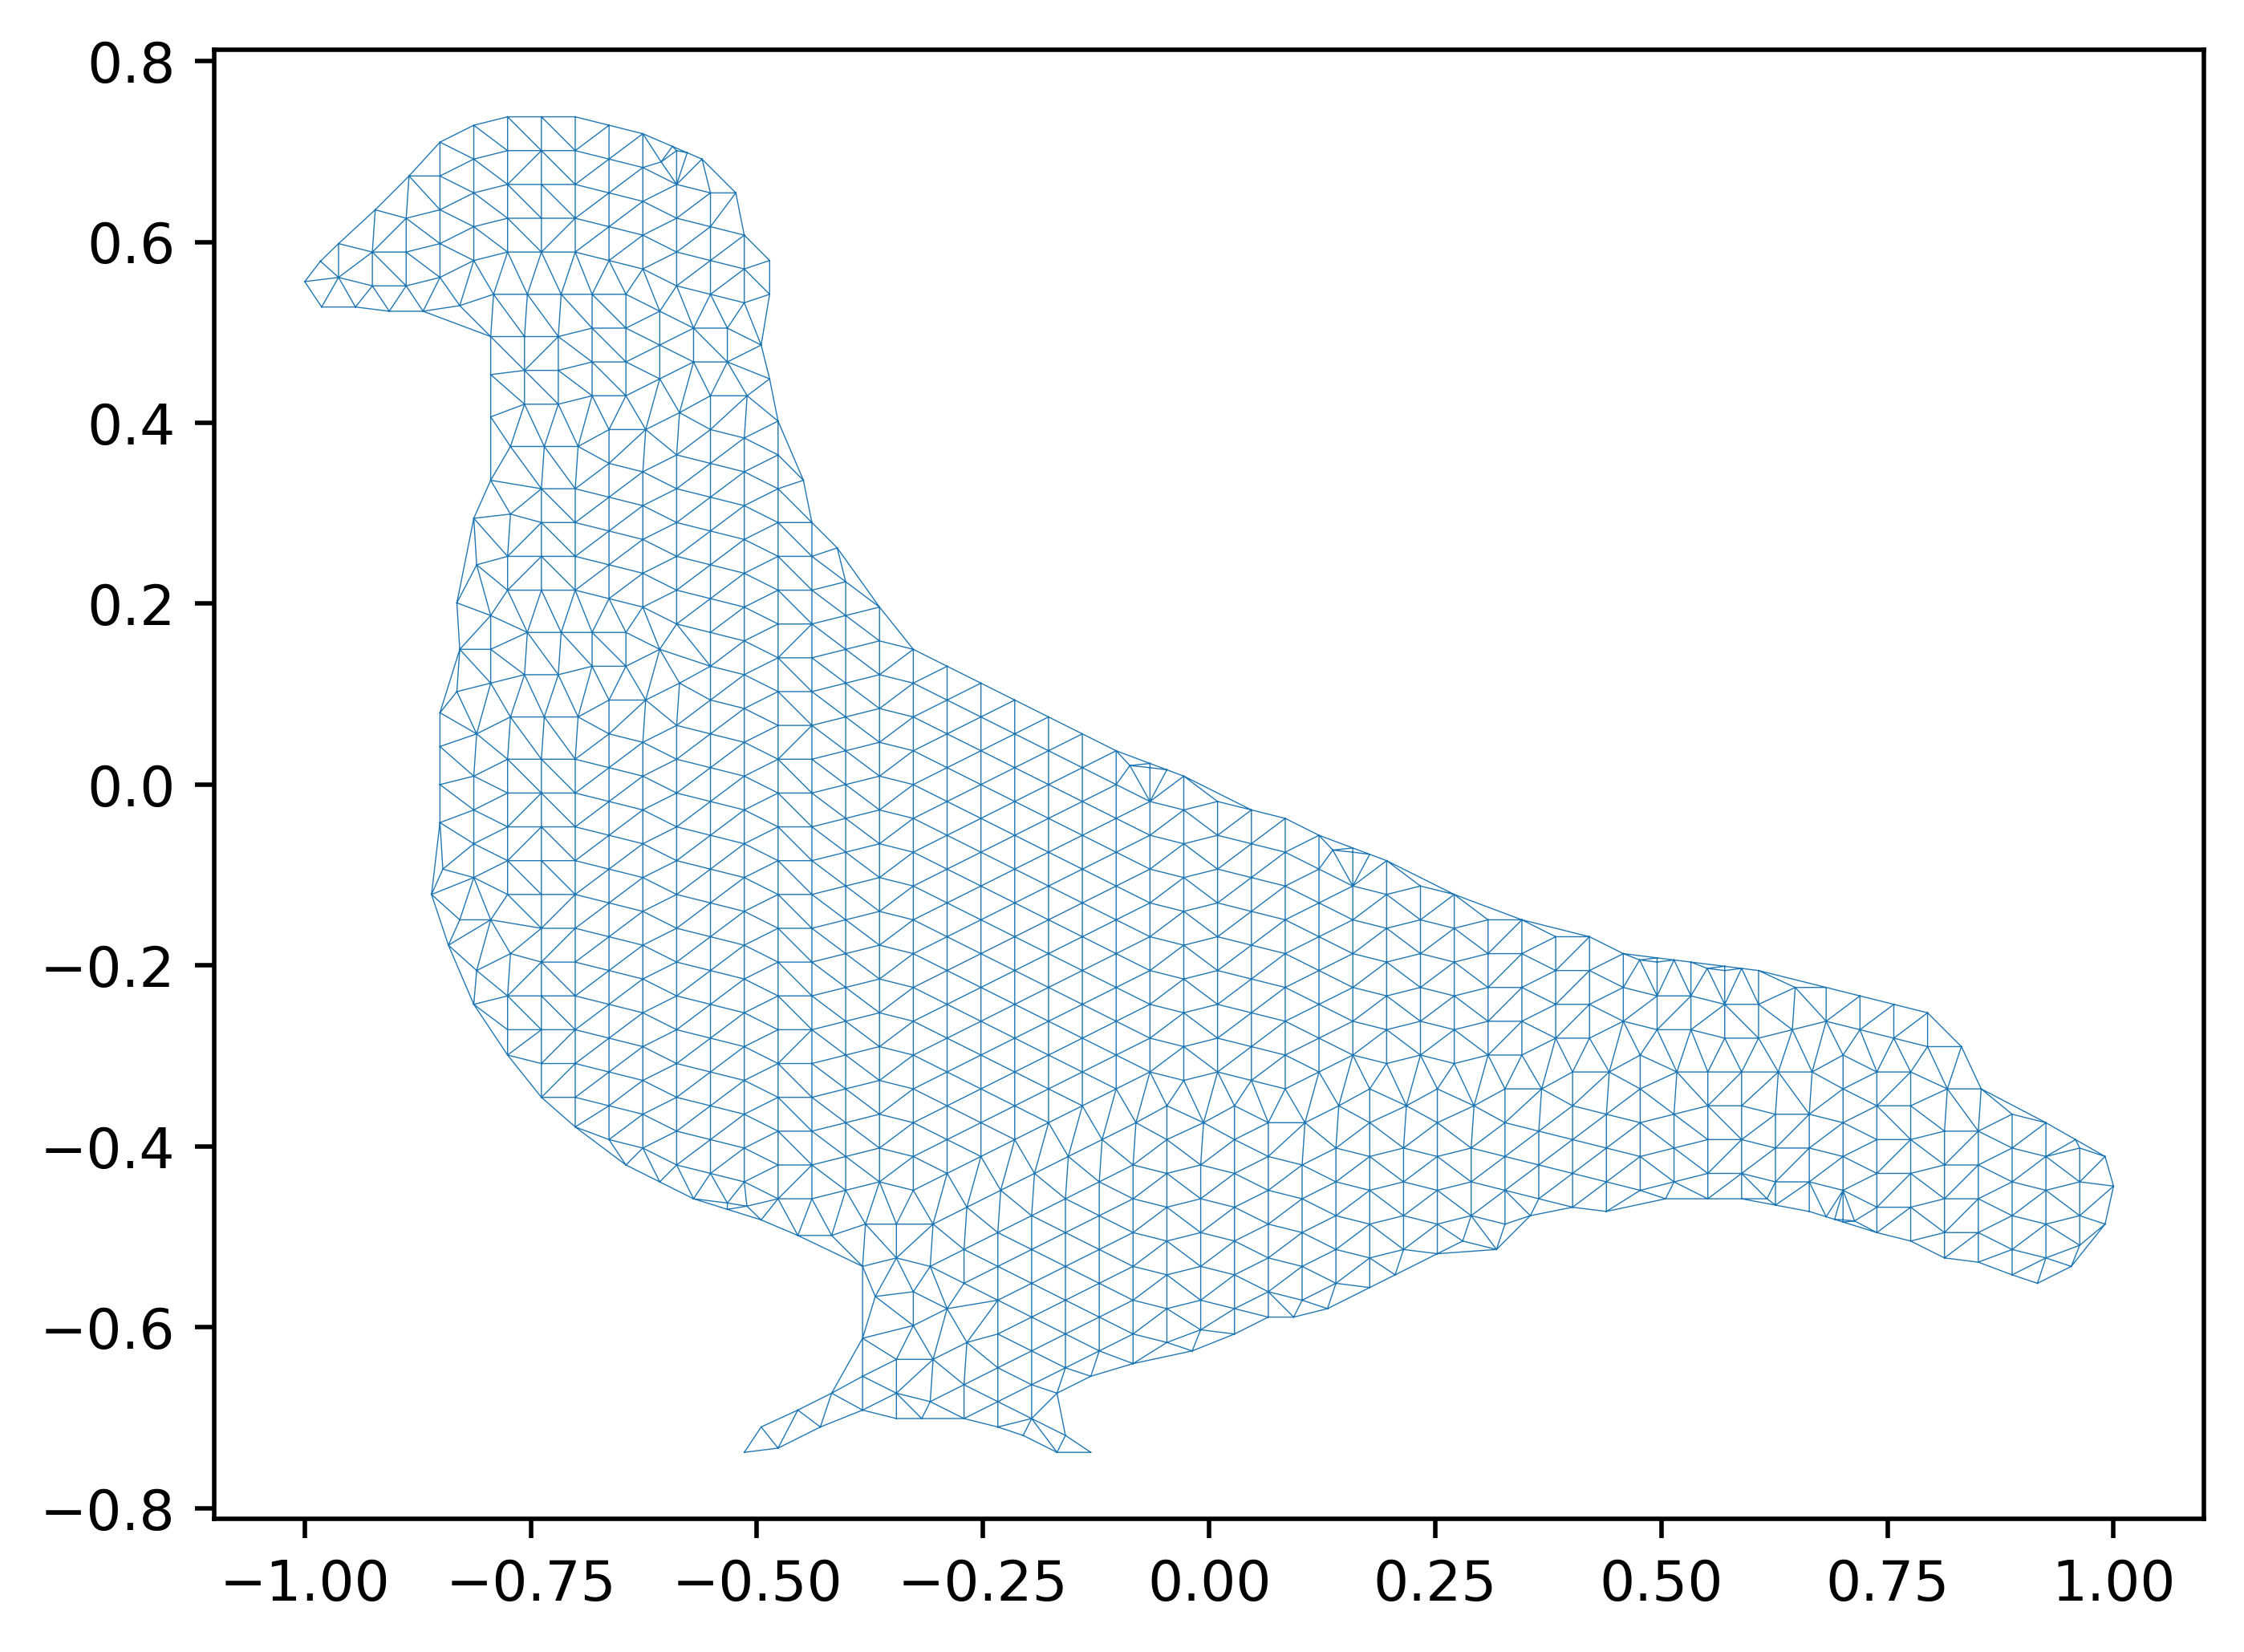

In [ ]:
dovedp = triangle.load("..\\meshes\\triangle_files", "dovedp")
dovedp_mesh = triangle.triangulate(dovedp, "pq10a150")

print(dovedp_mesh["vertices"].min(), dovedp_mesh["vertices"].max())
mins = dovedp_mesh["vertices"].min(axis=0)
maxs = dovedp_mesh["vertices"].max(axis=0)
# Center of the bounding box
center = 0.5 * (mins + maxs)

# Largest dimension of the bounding box
max_extent = np.max(maxs - mins)

# Normalizing mesh vertices range
dovedp_mesh["vertices"] = 2.0 * (dovedp_mesh["vertices"] - center) / max_extent
print(dovedp_mesh["vertices"].min(), dovedp_mesh["vertices"].max())

dovedp_mesh_obj = TriMesh(dovedp_mesh)
plot_mesh(dovedp_mesh)

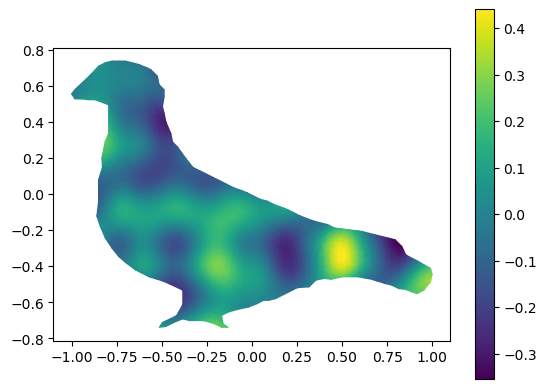

In [ ]:
mesh_noise = dovedp_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)
plot_noise_mesh(dovedp_mesh, mesh_noise)

(871,)
281
239
137
243
285
155
175

Resumo da cobertura:
  n_patches           : 7
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 137
  max_nodes           : 285
  mean_nodes          : 216.42857142857142
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 1.7393800229621126
  full_coverage       : True
(871,)


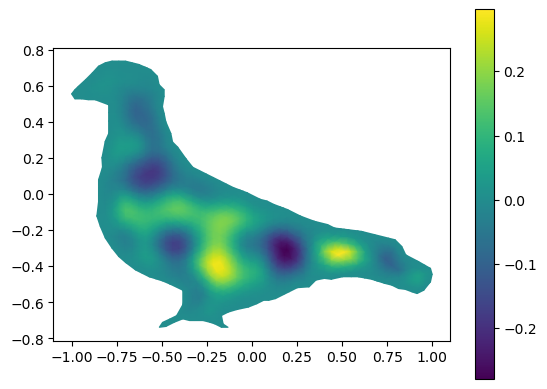

<Axes: title={'center': 'Coverage: 7 patches)'}>

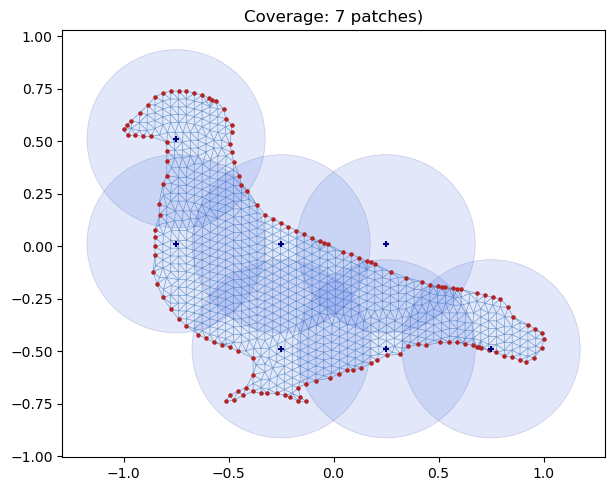

In [ ]:
dovedp_mesh_obj.sdf_distance_to_segments_min()
sdf = dovedp_mesh_obj.get_sdf_field()

coverage = PatchCoverage(dovedp_mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

potential_sdf = NoisePotential2D(dovedp_mesh_obj, coverage, RBF(epsilon=1.0))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.2)
plot_noise_mesh(dovedp_mesh, psi)

plot_patches(dovedp_mesh_obj, coverage, ax=None, title=f"Coverage: {len(coverage)} patches)")

In [ ]:
# With boundary treatment
potential_sdf.fit(psi)

# refining mesh
#pts, tri  = refine_mesh_1to4(dovedp_mesh["vertices"], dovedp_mesh["triangles"])
#fine_mesh = {}
#fine_mesh["vertices"] = pts
#fine_mesh["triangles"] = tri
#fine_mesh_obj = TriMesh(fine_mesh)

#fine_scalar_field = potential_sdf.evaluate(fine_mesh["vertices"])
grad_x, grad_y = potential_sdf.gradient(dovedp_mesh["vertices"])
curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))


dovedp_mesh_obj.save_mesh_paraview(dovedp_mesh, vels=curl, phi=mesh_noise,  psi=psi, out_name="dovedp_lic_psi.vtu", save_norm=True)

Normalization factor: 0.44059279537400853
Original normalized range:
-0.8034981512662339 1.0
Masked normalized range:
-0.632805869783187 0.6726704071511115
